## Torch Vision Object detection tutorial [link](https://docs.pytorch.org/tutorials/intermediate/torchvision_tutorial.html)

I will be finetuning a mask rcnn model using penn-fudan database for pedestrian detection and segmentation. 

The above sources can be accessed using the tutorial link above.

In [1]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [2]:
from pathlib import Path
import urllib.request
import zipfile

def download_dataset():
    data_dir = Path("datasets")
    url = "https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip"
    zip_path = data_dir / "PennFudanPed.zip"
    data_dir.mkdir(parents=True, exist_ok=True)

    if not zip_path.exists():
        print("Downloading...", end="")
        urllib.request.urlretrieve(url, zip_path)
        print("Done.")
    unzipped_path = data_dir / "PennFudanPed_data"
    if not unzipped_path.exists():
        print("Extracting...", end="")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(data_dir)
        print("Done.")
    return unzipped_path

pennfudanped_dir = download_dataset()

Extracting...Done.


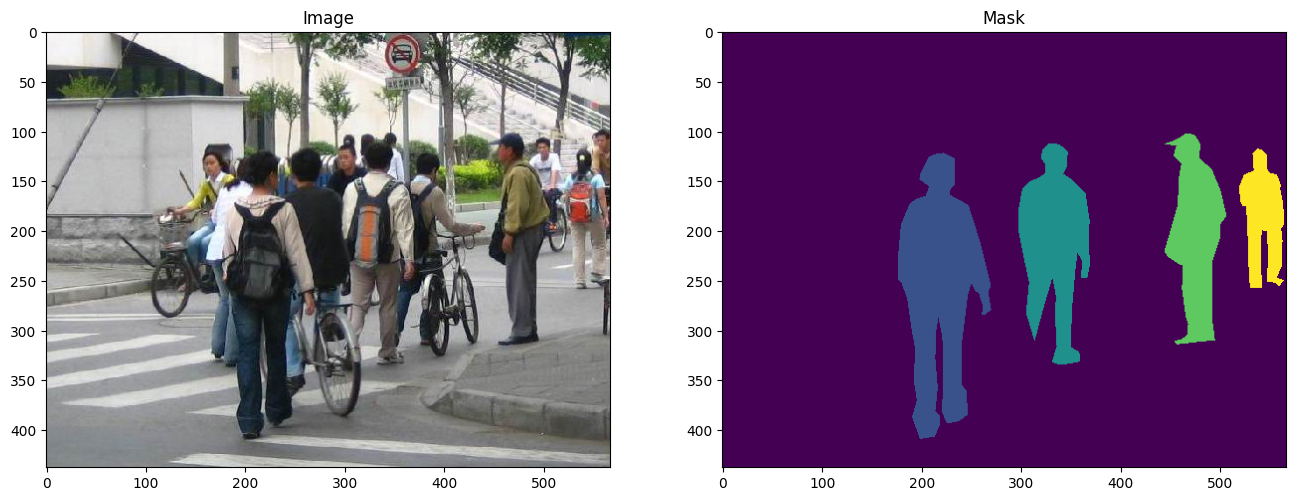

In [48]:
import matplotlib.pyplot as plt
from torchvision.io import read_image

image = read_image("datasets/PennFudanPed/PNGImages/FudanPed00046.png")
mask = read_image("datasets/PennFudanPed/PedMasks/FudanPed00046_mask.png")

plt.figure(figsize=(16, 8))
plt.subplot(121)
plt.title("Image")
plt.imshow(image.permute(1,2,0))
plt.subplot(122)
plt.title("Mask")
plt.imshow(mask.permute(1,2,0))
plt.axis()
plt.savefig("plot.png")

### Writing a custom dataset for PennFudan

In [24]:
import os
from torchvision.io import read_image
from torchvision.ops.boxes import masks_to_boxes
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F

class PennFudanDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms):
        self.root = root
        self.transforms = transforms
        # load all the files, ensuring that they are aligned.
        self.imgs = list(sorted(os.listdir(os.path.join(root,"PNGImages"))))
        self.masks = list(sorted(os.listdir(os.path.join(root, "PedMasks"))))
    
    def __getitem__(self, idx):
        # load images and mask
        img_path = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "PedMasks", self.masks[idx])
        image = read_image(img_path)
        mask = read_image(mask_path)

        #scan the mask and find all distinct pixel values
        obj_ids = torch.unique(mask)
        #first id is background, so we just remove it
        obj_ids = obj_ids[1:]
        nums_objs = len(obj_ids)

        #splitting color encoded mask into set of binary mask
        masks = (mask == obj_ids[:, None, None]).to(dtype=torch.uint8)

        #calculate a bounding box
        boxes = masks_to_boxes(masks)

        #there is only one label
        labels = torch.ones((nums_objs,), dtype=torch.int64)

        image_id = idx
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])

        #suppose all instances are not crowd
        iscrowd = torch.zeros((nums_objs,), dtype=torch.int64)

        #wrap up the sample and targets into torchvision tv_tensors
        img = tv_tensors.Image(image)

        target = {}
        target["boxes"] = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=F.get_size(img))
        target["masks"] = tv_tensors.Mask(masks)
        target["labels"] = labels
        target["area"] = area
        target["iscrowd"] = iscrowd
        target["image_id"] = image_id

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target
    
    def __len__(self):
        return len(self.imgs)


### Defining the model
#### 1 - Finetuning from a pretrained model

In [25]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

num_classes = 2 # 1 classs (person) + background

in_features = model.roi_heads.box_predictor.cls_score.in_features

#replace the pretrained head with a new one
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)


In [26]:
predictor = FastRCNNPredictor(1024, 2)
predictor

FastRCNNPredictor(
  (cls_score): Linear(in_features=1024, out_features=2, bias=True)
  (bbox_pred): Linear(in_features=1024, out_features=8, bias=True)
)

In [27]:
model.roi_heads

RoIHeads(
  (box_roi_pool): MultiScaleRoIAlign(featmap_names=['0', '1', '2', '3'], output_size=(7, 7), sampling_ratio=2)
  (box_head): TwoMLPHead(
    (fc6): Linear(in_features=12544, out_features=1024, bias=True)
    (fc7): Linear(in_features=1024, out_features=1024, bias=True)
  )
  (box_predictor): FastRCNNPredictor(
    (cls_score): Linear(in_features=1024, out_features=2, bias=True)
    (bbox_pred): Linear(in_features=1024, out_features=8, bias=True)
  )
)

#### 2 - Modifying the model to add a different backbone

In [28]:
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator

# load a pre trained model for classification and return only the features
backbone = torchvision.models.mobilenet_v2(weights="DEFAULT").features

backbone

Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU6(inplace=True)
  )
  (1): InvertedResidual(
    (conv): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (2): InvertedResidual(
    (conv): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (

In [29]:
backbone.out_channels = 1280
backbone.out_channels

1280

In [30]:
# anchor generator with 5 different sizes and 3 aspect ratios

anchor_generator = AnchorGenerator(
    sizes=((32, 64, 128, 256, 512),),
    aspect_ratios=((0.5, 1.0, 2.0),)
)

#regions of interest with size of output after cropping
roi_pooler = torchvision.ops.MultiScaleRoIAlign(
    featmap_names=["0"],
    output_size=7,
    sampling_ratio=2
)


In [31]:
# putting the pieces together

model = FasterRCNN(
    backbone,
    num_classes=2,
    rpn_anchor_generator=anchor_generator,
    box_roi_pool=roi_pooler
)

### Object Detection and instance segmentation model for PennFudan Datasset

In our case, we want to finetune from a pretrained model and given that our dataset is very small, we will be following apporach number 1.

In [32]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

def get_model_instance_segmentation(num_classes):

    #load an instance segmentation model trained on coco dataset
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

    #get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    #replace the pre trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256

    #replace the mask predictor with a new one
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask, 
        hidden_layer,
        num_classes
    )
    return model


### Putting Everything Together

In [33]:
from pathlib import Path

files_list = ["coco_eval.py", "coco_utils.py", "engine.py", "transforms.py", "utils.py"]

def get_file(file_name):
    file_path = Path(file_name)
    if file_path.exists():
        print(f"{file_name} already exists. Skipping download.")
        return
    os.system(f"wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/{file_name}")

for file_name in files_list:
    get_file(file_name)


coco_eval.py already exists. Skipping download.
coco_utils.py already exists. Skipping download.
engine.py already exists. Skipping download.
transforms.py already exists. Skipping download.
utils.py already exists. Skipping download.


Some helper functions for data augmentation / transformation

In [34]:
from torchvision.transforms import v2 as T

def get_transform(train):
    transforms = []
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    transforms.append(T.ToDtype(torch.float, scale=True))
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)

### Testing `forward()` method

In [35]:
import utils

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
dataset = PennFudanDataset("datasets/PennFudanPed", get_transform(train=True))
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=utils.collate_fn
)

In [36]:
#For Training

images,targets = next(iter(data_loader))
images = list(image for image in images)
targets = [{k: v for k, v in t.items()} for t in targets]
output = model(images, targets)
print(output)

{'loss_classifier': tensor(0.1556, grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0538, grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0419, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0034, grad_fn=<DivBackward0>)}


In [37]:
# For inference 
model.eval()
x = [torch.rand(3,300,400), torch.rand(3,500,400)]
predictions = model(x)
print(predictions)

[{'boxes': tensor([], size=(0, 4), grad_fn=<StackBackward0>), 'labels': tensor([], dtype=torch.int64), 'scores': tensor([], grad_fn=<IndexBackward0>)}, {'boxes': tensor([], size=(0, 4), grad_fn=<StackBackward0>), 'labels': tensor([], dtype=torch.int64), 'scores': tensor([], grad_fn=<IndexBackward0>)}]


In [38]:
from engine import train_one_epoch, evaluate

#train on the accelerator or on cpu if accelerator is not available
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else torch.device("cpu")
device

device(type='cuda')

In [39]:
from torch.utils.data import Subset
from torch.utils.data import DataLoader

#our dataset has 2 classes - background and person
num_classes = 2

#train and test dataset
dataset = PennFudanDataset("datasets/PennFudanPed", get_transform(train=True))
dataset_test = PennFudanDataset("datasets/PennFudanPed", get_transform(train=False))

#split into test and train
indices = torch.randperm(len(dataset)).tolist()
dataset = Subset(dataset, indices[:-50])
dataset_test = Subset(dataset_test, indices[-50:])

#define dataloaders and validation loaders
data_loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=utils.collate_fn
)

data_loader_test = DataLoader(
    dataset_test,
    batch_size=1,
    shuffle=False,
    collate_fn=utils.collate_fn
)

# get the model using our helper functio
model = get_model_instance_segmentation(num_classes=2)
model.to(device)

#parameters and optimization function
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
num_epochs = 2

In [40]:
next(iter(data_loader))

((tensor([[[0.2275, 0.2314, 0.2745,  ..., 0.1725, 0.1686, 0.1608],
           [0.2314, 0.1961, 0.2588,  ..., 0.1725, 0.1686, 0.1608],
           [0.2078, 0.1922, 0.2078,  ..., 0.1725, 0.1647, 0.1569],
           ...,
           [0.4000, 0.4000, 0.3922,  ..., 0.4353, 0.4353, 0.4353],
           [0.4039, 0.4196, 0.4078,  ..., 0.4431, 0.4431, 0.4431],
           [0.4078, 0.3922, 0.3882,  ..., 0.4353, 0.4392, 0.4549]],
  
          [[0.2275, 0.2235, 0.2627,  ..., 0.4275, 0.4235, 0.4157],
           [0.2314, 0.1961, 0.2510,  ..., 0.4275, 0.4235, 0.4157],
           [0.2078, 0.1922, 0.2000,  ..., 0.4275, 0.4196, 0.4118],
           ...,
           [0.4000, 0.4000, 0.3922,  ..., 0.4431, 0.4431, 0.4431],
           [0.4039, 0.4196, 0.4078,  ..., 0.4510, 0.4510, 0.4510],
           [0.4078, 0.3922, 0.3882,  ..., 0.4392, 0.4431, 0.4588]],
  
          [[0.1882, 0.1725, 0.2039,  ..., 0.8196, 0.8157, 0.8078],
           [0.1922, 0.1490, 0.2000,  ..., 0.8196, 0.8157, 0.8078],
           [0.1765, 0.

In [41]:
for epoch in range(num_epochs):
    # train for one epoch, printing every 10 iterations
    train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=10)
    # update the learning rate
    lr_scheduler.step()
    # evaluate on the test dataset
    evaluate(model, data_loader_test, device=device)



/home/krekken/Hands-on-ML/Object_Detection/engine.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Epoch: [0]  [ 0/60]  eta: 0:00:30  lr: 0.000090  loss: 5.6508 (5.6508)  loss_classifier: 0.7636 (0.7636)  loss_box_reg: 0.2162 (0.2162)  loss_mask: 4.6332 (4.6332)  loss_objectness: 0.0348 (0.0348)  loss_rpn_box_reg: 0.0030 (0.0030)  time: 0.5003  data: 0.0198  max mem: 2608
Epoch: [0]  [10/60]  eta: 0:00:22  lr: 0.000936  loss: 1.8209 (3.0261)  loss_classifier: 0.4986 (0.4671)  loss_box_reg: 0.3052 (0.2933)  loss_mask: 1.1897 (2.2362)  loss_objectness: 0.0191 (0.0235)  loss_rpn_box_reg: 0.0053 (0.0059)  time: 0.4508  data: 0.0202  max mem: 2959
Epoch: [0]  [20/60]  eta: 0:00:18  lr: 0.001783  loss: 1.0597 (1.9712)  loss_classifier: 0.2339 (0.3383)  loss_box_reg: 0.2922 (0.2906)  loss_mask: 0.4479 (1.3124)  loss_objectness: 0.0188 (0.0205)  loss_rpn_box_reg: 0.0085 (0.0094)  time: 0.4659  data: 0.0223  max mem: 2959
Epoch: [0]  [30/60]  eta: 0:00:13  lr: 0.002629  loss: 0.6035 (1.4971)  loss_classifier: 0.1103 (0.2561)  loss_box_reg: 0.2393 (0.2544)  loss_mask: 0.2417 (0.9611)  loss_ob

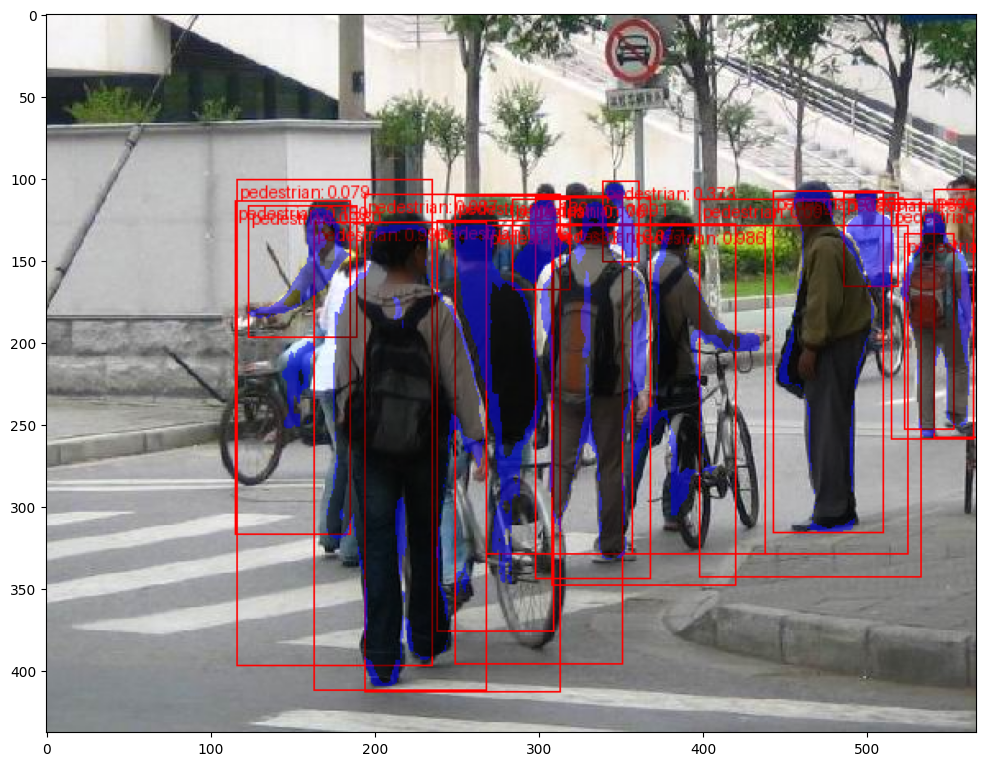

In [46]:
import matplotlib.pyplot as plt
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks

image = read_image("datasets/PennFudanPed/PNGImages/FudanPed00046.png")
eval_transform = get_transform(train=False)

model.eval()
with torch.no_grad():
    x = eval_transform(image)
    #convert RGBA to RGB and move to device
    x = x[:3,...].to(device)
    predictions = model([x,])
    pred = predictions[0]

image = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
image = image[:3,...]
pred_labels = [f"pedestrian: {score:.3f}" for label, score in zip(pred["labels"], pred["scores"])]
pred_boxes = pred["boxes"].long()
output_image = draw_bounding_boxes(image, pred_boxes, pred_labels, colors="red")

masks = (pred["masks"] > 0.7).squeeze(1)
output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")

plt.figure(figsize=(12,12))
plt.imshow(output_image.permute(1,2,0))
